<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/GFP_intensity_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

pip install nd2 matplotlib tifffile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.1/102.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 21.0 MB/s eta 0:00:00


Extracting frames...
Exported Vector Layout: HF_vs_NF_GFP_intensity_Comparison.svg
Exported Lossless Raster: HF_vs_NF_GFP_intensity_Comparison.tiff


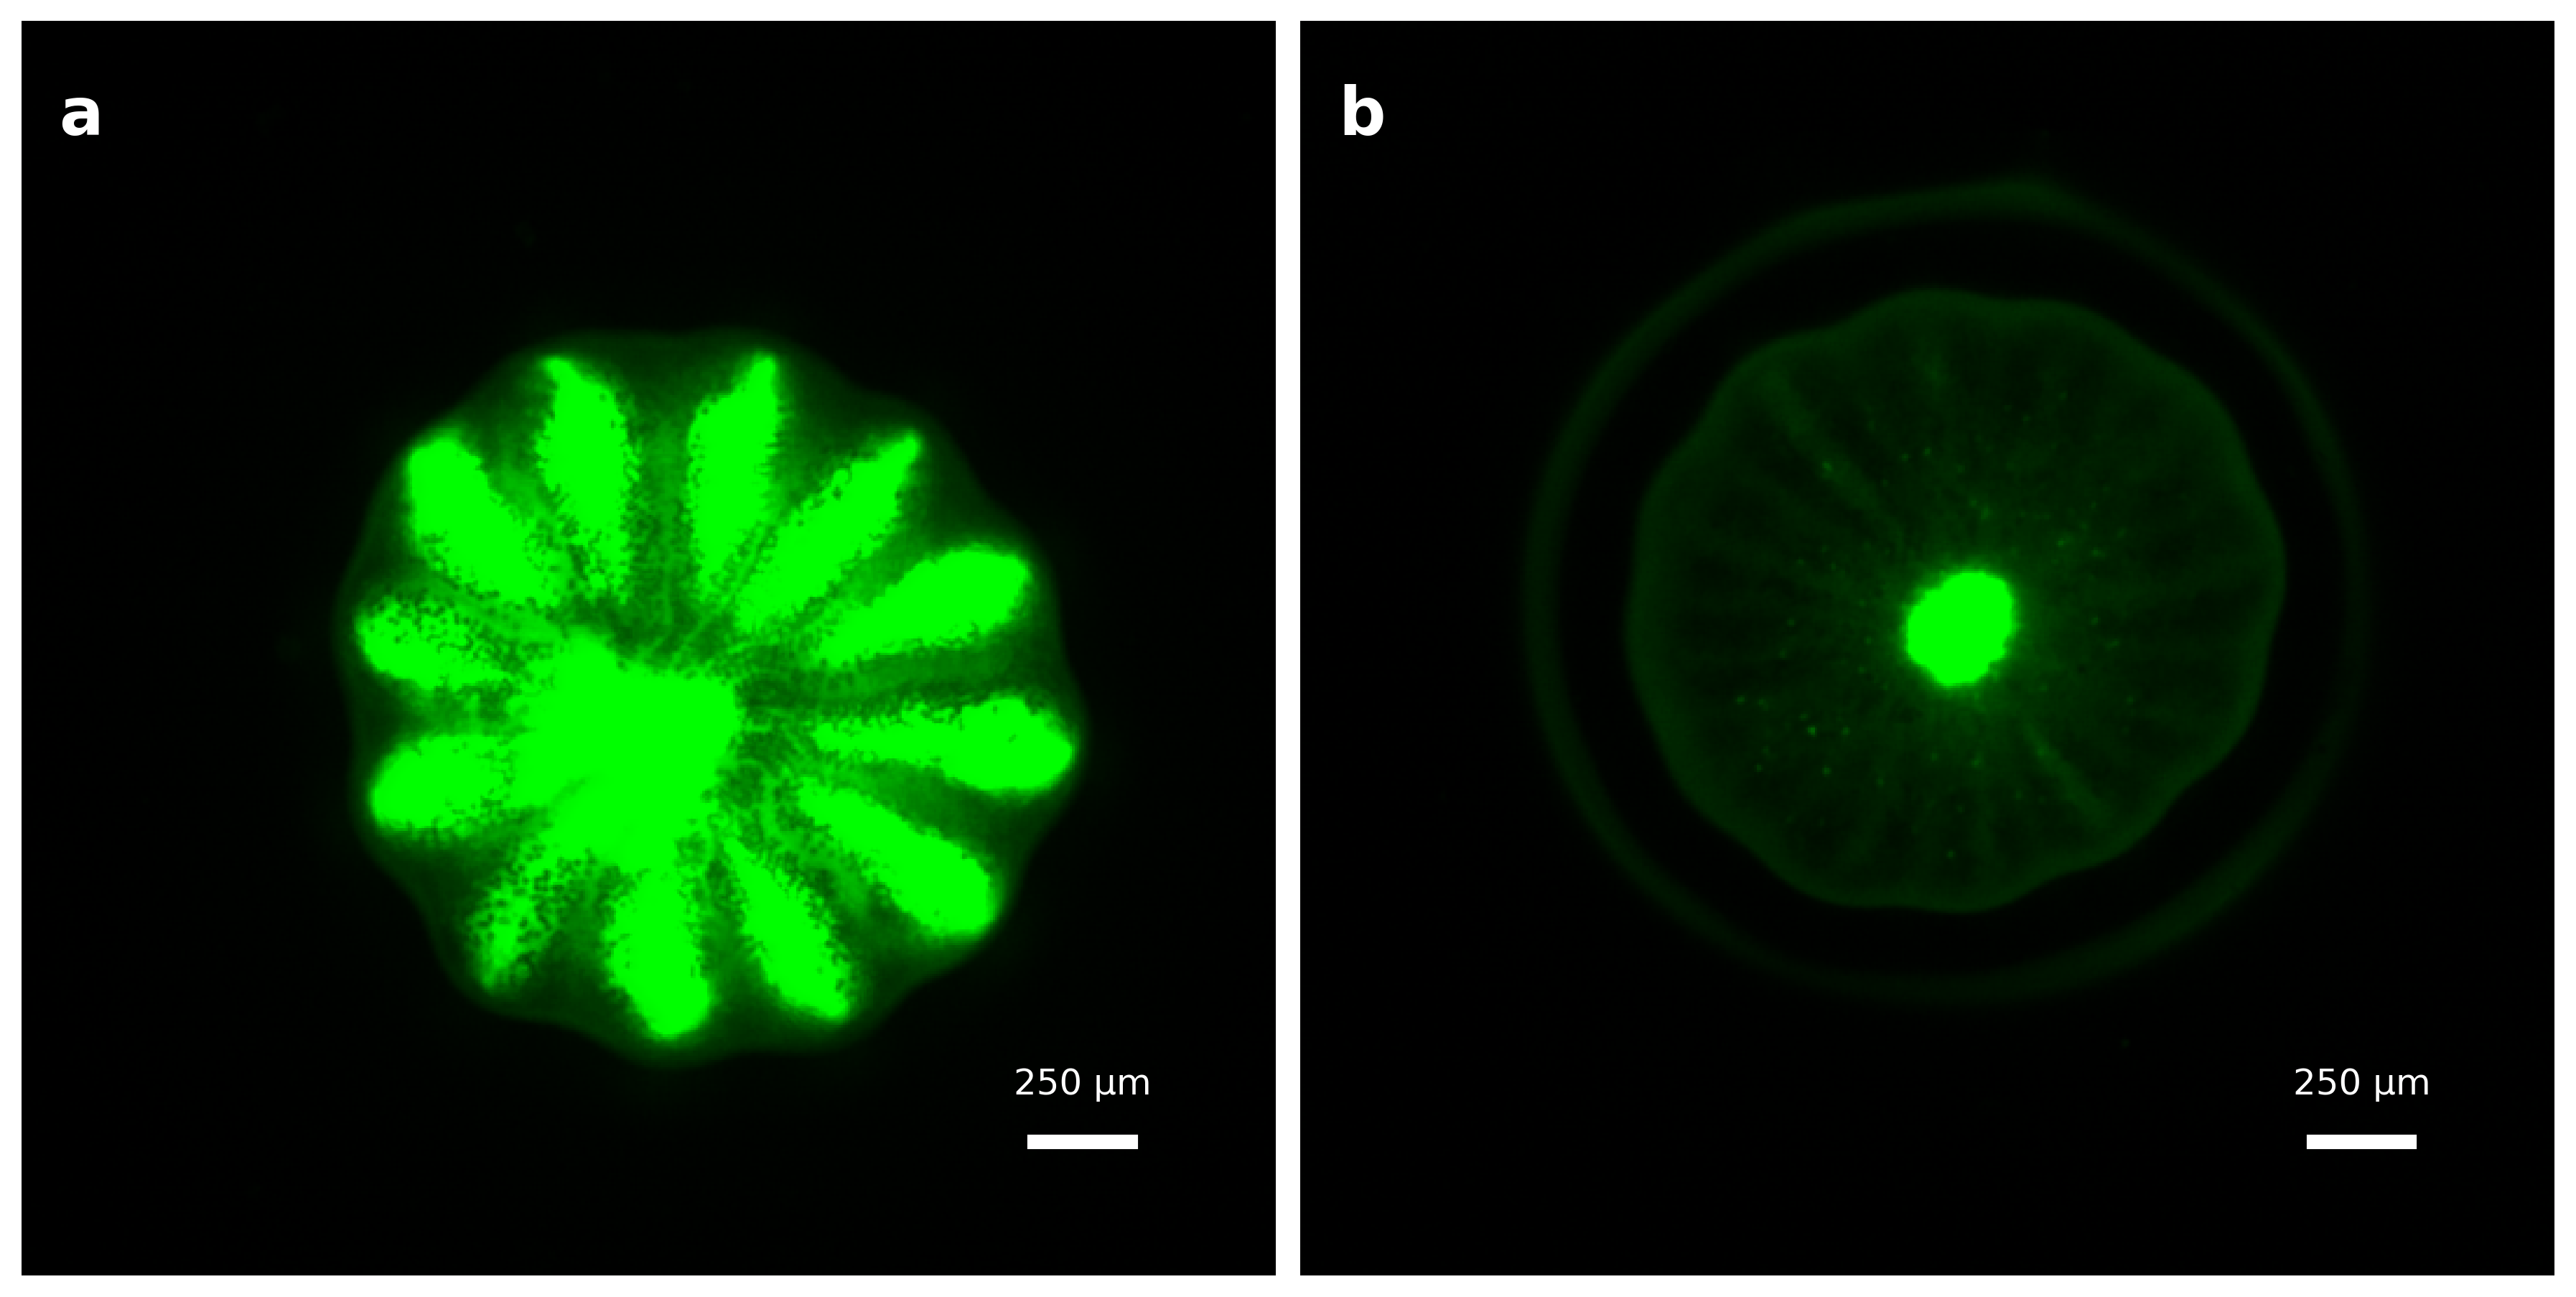

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import nd2
import tifffile

# 1. File path configurations
hf_path = 'HF_GFP_X4.nd2'
nf_path = 'NF_GFP_X4.nd2'

def read_and_project_nd2(file_path):
    """Opens ND2, applies Max Intensity Projection for Z-stacks, returns matrix."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Target file '{file_path}' not found.")

    with nd2.ND2File(file_path) as nd_file:
        voxel_size = nd_file.voxel_size()
        pixel_size_um = voxel_size.x if voxel_size else 1.0
        img_array = nd_file.asarray()
        axes = nd_file.sizes

        # Collapse Z-stack via Max Intensity Projection if present
        if 'Z' in axes:
            z_axis_idx = list(axes.keys()).index('Z')
            img_array = np.max(img_array, axis=z_axis_idx)

        # Select target fluorescent channel index
        if 'C' in axes and img_array.ndim > 2:
            img_array = img_array[0]

        return img_array, pixel_size_um

# 2. Extract matrix arrays and scales
print("Extracting frames...")
hf_img, hf_scale = read_and_project_nd2(hf_path)
nf_img, nf_scale = read_and_project_nd2(nf_path)

# 3. Contrast enhancement normalization
def normalize_contrast(img):
    img_float = img.astype(float)
    min_val, max_val = np.percentile(img_float, (0.5, 99.5))
    clipped = np.clip(img_float, min_val, max_val)
    return (clipped - min_val) / (max_val - min_val)

hf_norm = normalize_contrast(hf_img)
nf_norm = normalize_contrast(nf_img)

# 4. Define True Fluorescent Green Colormap (Black to Vibrant Lime Green)
fluo_green = LinearSegmentedColormap.from_list("fluo_green", ["black", "#00FF00"])

# 5. Generate high-resolution publication figure canvas
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), dpi=300)
plt.subplots_adjust(wspace=0.02, hspace=0, left=0.01, right=0.99, bottom=0.01, top=0.99)

scale_bar_len_um = 250

# --- PANEL a: High-Fluorescent Cohort ---
axes[0].imshow(hf_norm, cmap=fluo_green)
axes[0].axis('off')
axes[0].text(0.03, 0.95, 'a', transform=axes[0].transAxes, color='white',
             fontsize=22, fontweight='bold', va='top', ha='left')

# Scale bar math panel a
scale_bar_px_hf = scale_bar_len_um / hf_scale
height_hf, width_hf = hf_norm.shape
# Horizontal bar only
axes[0].add_patch(Rectangle((width_hf - scale_bar_px_hf - 60, height_hf - 60),
                            scale_bar_px_hf, 5, color='white'))
axes[0].text(width_hf - (scale_bar_px_hf / 2) - 60, height_hf - 75, f'{scale_bar_len_um} µm',
             color='white', fontsize=12, ha='center', va='bottom')

# --- PANEL b: Non-Fluorescent Cohort ---
axes[1].imshow(nf_norm, cmap=fluo_green)
axes[1].axis('off')
axes[1].text(0.03, 0.95, 'b', transform=axes[1].transAxes, color='white',
             fontsize=22, fontweight='bold', va='top', ha='left')

# Scale bar math panel b
scale_bar_px_nf = scale_bar_len_um / nf_scale
height_nf, width_nf = nf_norm.shape
# Horizontal bar only
axes[1].add_patch(Rectangle((width_nf - scale_bar_px_nf - 60, height_nf - 60),
                            scale_bar_px_nf, 5, color='white'))
axes[1].text(width_nf - (scale_bar_px_nf / 2) - 60, height_nf - 75, f'{scale_bar_len_um} µm',
             color='white', fontsize=12, ha='center', va='bottom')

# 6. Export high-fidelity vector and raster configurations
svg_output = 'HF_vs_NF_GFP_intensity_Comparison.svg'
plt.savefig(svg_output, format='svg', bbox_inches='tight', pad_inches=0, dpi=600)
print(f"Exported Vector Layout: {svg_output}")

tiff_output = 'HF_vs_NF_GFP_intensity_Comparison.tiff'
plt.savefig(tiff_output, format='tiff', bbox_inches='tight', pad_inches=0, dpi=600,
            pil_kwargs={"compression": "tiff_lzw"})
print(f"Exported Lossless Raster: {tiff_output}")

plt.show()

Exported Vertical Vector: HF_vs_NF_GFP_intensity_Comparison_Vertical.svg
Exported Vertical Raster: HF_vs_NF_GFP_intensity_Comparison_Vertical.tiff


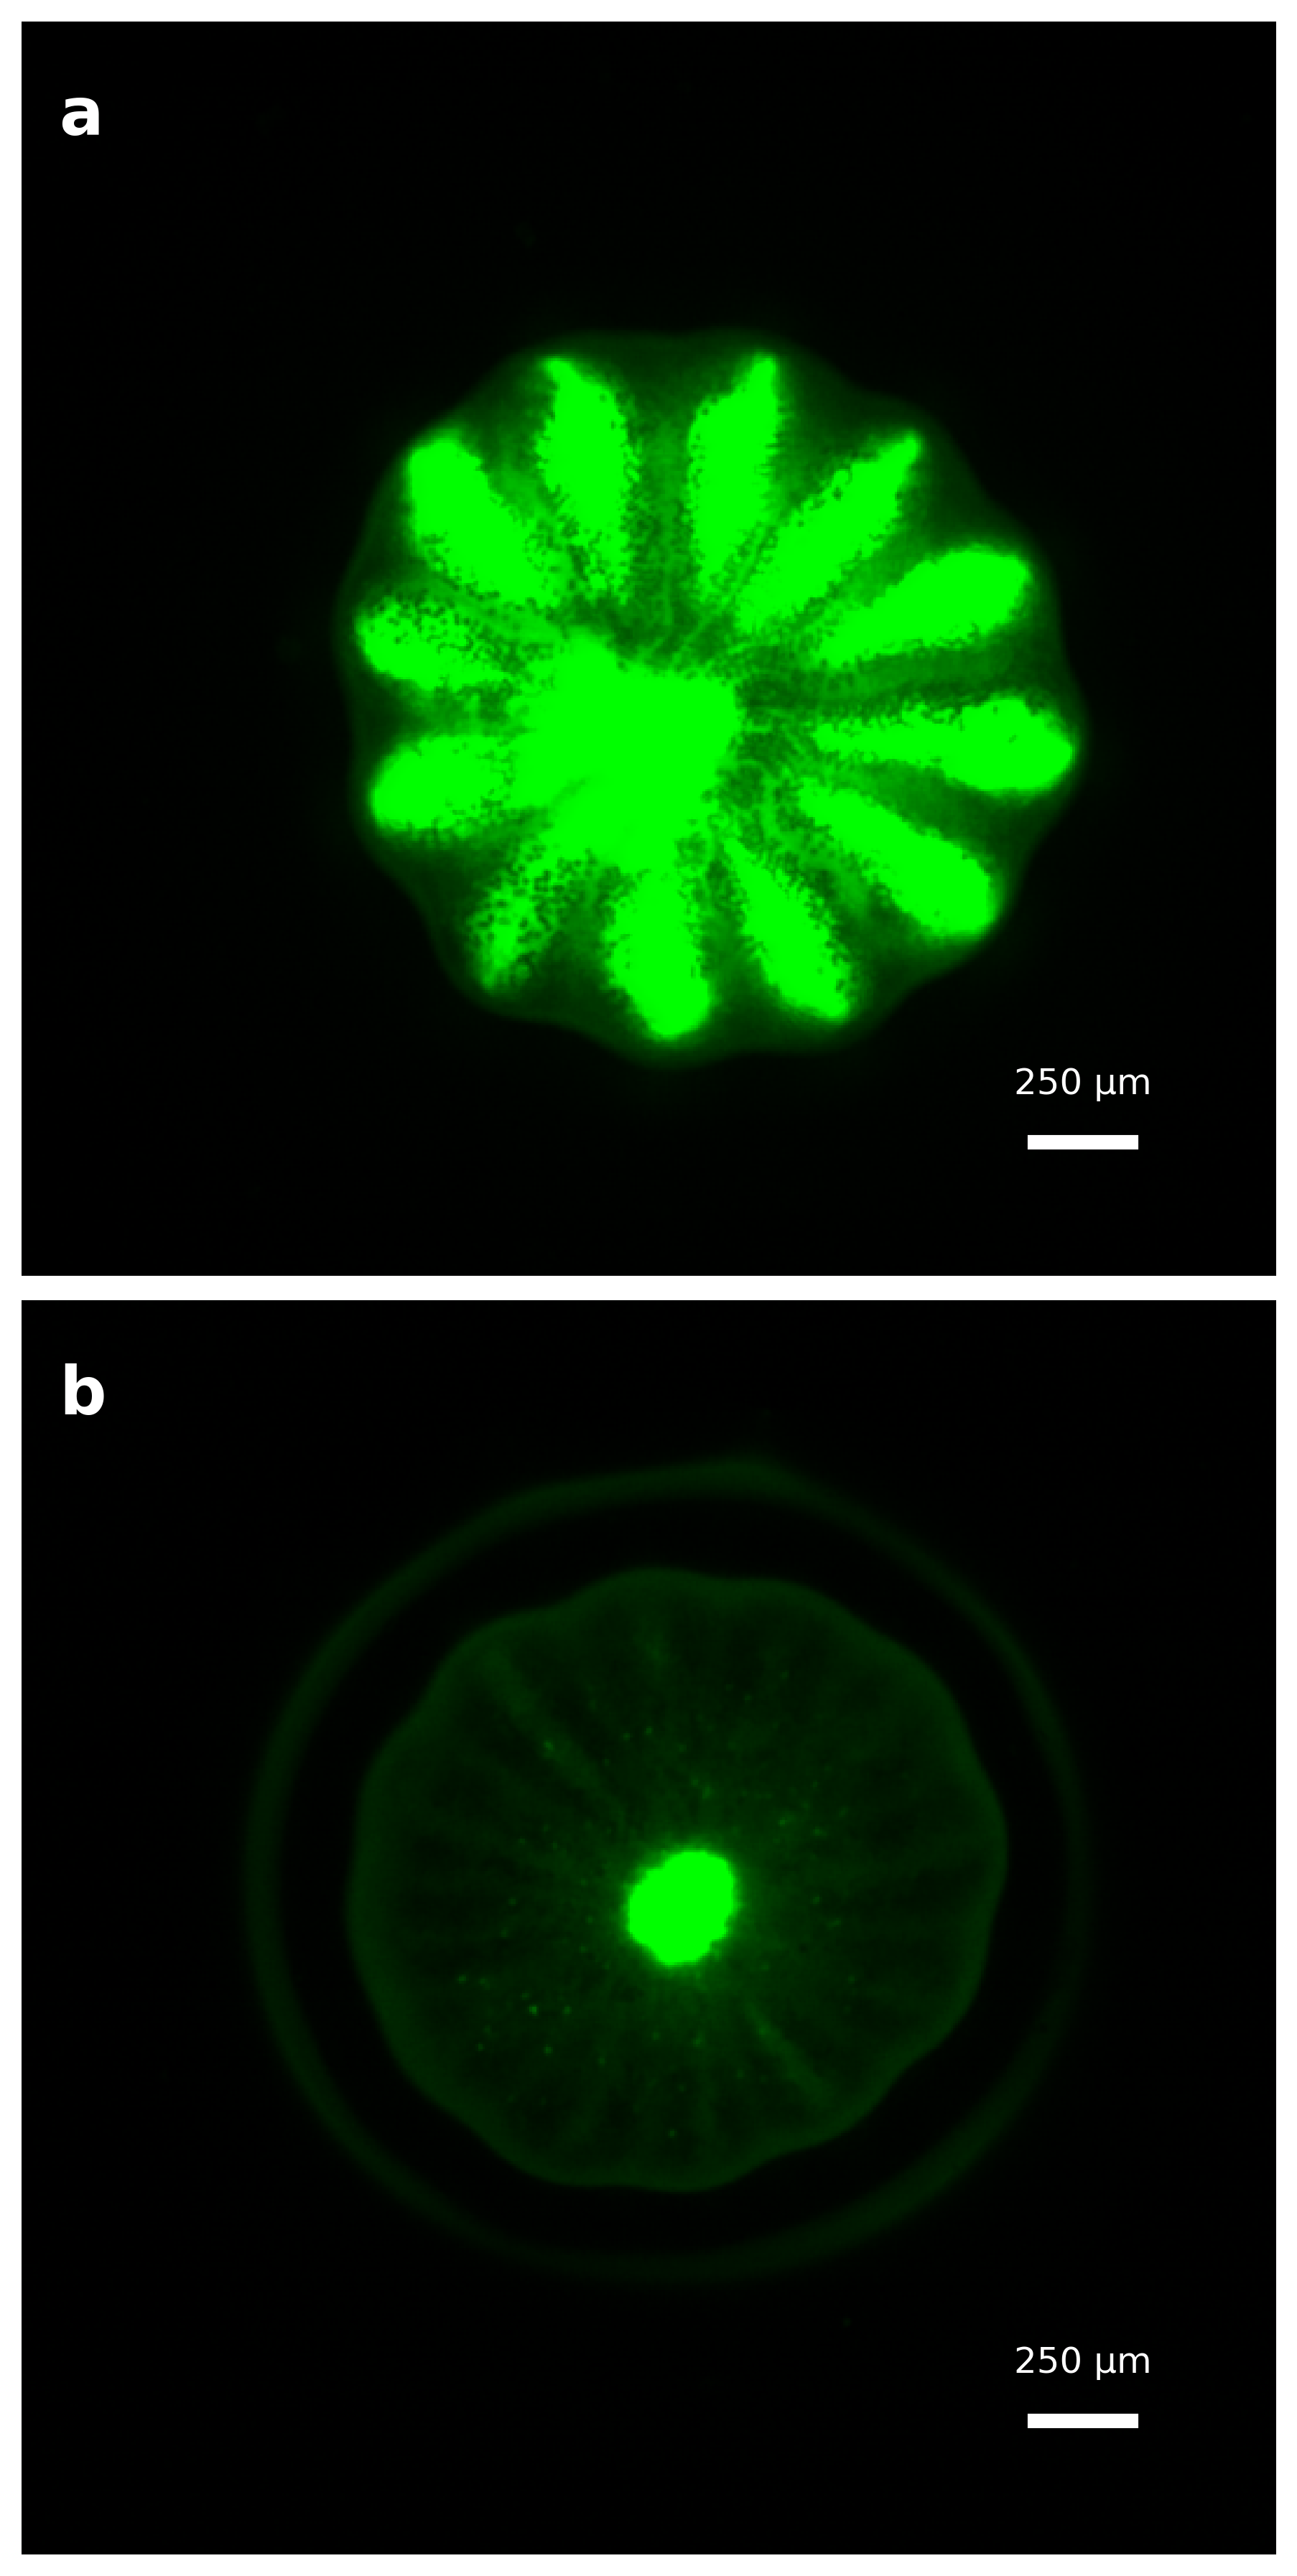

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 5. Generate Vertical Figure (2 rows, 1 column)
# Adjusting figsize for vertical orientation
fig_v, axes_v = plt.subplots(2, 1, figsize=(6.5, 12), dpi=300)
plt.subplots_adjust(wspace=0, hspace=0.02, left=0.01, right=0.99, bottom=0.01, top=0.99)

# --- PANEL a: High-Fluorescent Cohort (Top) ---
axes_v[0].imshow(hf_norm, cmap=fluo_green)
axes_v[0].axis('off')
axes_v[0].text(0.03, 0.95, 'a', transform=axes_v[0].transAxes, color='white',
               fontsize=22, fontweight='bold', va='top', ha='left')

# Horizontal bar
axes_v[0].add_patch(Rectangle((width_hf - scale_bar_px_hf - 60, height_hf - 60),
                              scale_bar_px_hf, 5, color='white'))
axes_v[0].text(width_hf - (scale_bar_px_hf / 2) - 60, height_hf - 75, f'{scale_bar_len_um} µm',
               color='white', fontsize=12, ha='center', va='bottom')

# --- PANEL b: Non-Fluorescent Cohort (Bottom) ---
axes_v[1].imshow(nf_norm, cmap=fluo_green)
axes_v[1].axis('off')
axes_v[1].text(0.03, 0.95, 'b', transform=axes_v[1].transAxes, color='white',
               fontsize=22, fontweight='bold', va='top', ha='left')

# Horizontal bar
axes_v[1].add_patch(Rectangle((width_nf - scale_bar_px_nf - 60, height_nf - 60),
                              scale_bar_px_nf, 5, color='white'))
axes_v[1].text(width_nf - (scale_bar_px_nf / 2) - 60, height_nf - 75, f'{scale_bar_len_um} µm',
               color='white', fontsize=12, ha='center', va='bottom')

# 6. Export vertical layouts
svg_v_output = 'HF_vs_NF_GFP_intensity_Comparison_Vertical.svg'
tiff_v_output = 'HF_vs_NF_GFP_intensity_Comparison_Vertical.tiff'

plt.savefig(svg_v_output, format='svg', bbox_inches='tight', pad_inches=0, dpi=600)
plt.savefig(tiff_v_output, format='tiff', bbox_inches='tight', pad_inches=0, dpi=600, pil_kwargs={"compression": "tiff_lzw"})

print(f"Exported Vertical Vector: {svg_v_output}")
print(f"Exported Vertical Raster: {tiff_v_output}")

plt.show()